# Earth Observation

## Q1. Spatial Reasoning & Data Filtering 
1. Plot the Delhi-NCR shapefile using matplotlib and overlay a 60×60 km uniform grid 
2. Filter satellite images whose center coordinates fall inside the region.
3. Report the total number of images before and after filtering.

In [183]:
import os
import math
import geopandas as gpd
from shapely.geometry import box, Point
import matplotlib.pyplot as plt
import pandas as pd

In [184]:
NCR_SHAPEFILE = "data/delhi_ncr_region.geojson"
NCR_GDF = gpd.read_file(NCR_SHAPEFILE)

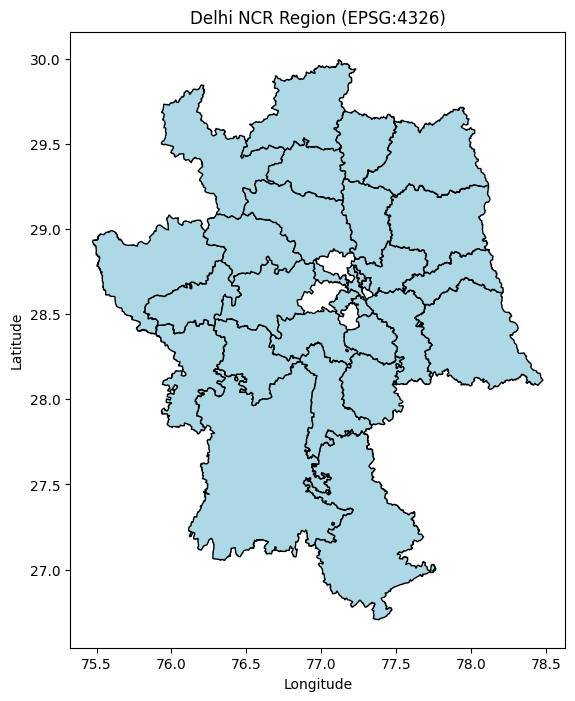

In [185]:
fig, ax = plt.subplots(figsize=(8,8))

NCR_GDF.plot(ax=ax, edgecolor="black", facecolor="lightblue")

ax.set_title("Delhi NCR Region (EPSG:4326)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

In [186]:
# xyz_gdf --> EPSG:4326
# xyz_gdf_proj --> EPSG:32644

In [187]:
print("Shapefile CRS:", NCR_GDF.crs)

if NCR_GDF.crs is None:
    print("CRS is not defined. Setting to EPSG:4326.")
    NCR_GDF.set_crs(epsg=4326, inplace=True)

ncr_proj = NCR_GDF.to_crs(epsg=32644)
print("Projected CRS:", ncr_proj.crs)

Shapefile CRS: EPSG:4326
Projected CRS: EPSG:32644


In [188]:
cell_size = 60000       # 60 km in meters
minx, miny, maxx, maxy = ncr_proj.total_bounds

cols = list(range(int(math.floor(minx)), int(math.ceil(maxx)), cell_size))
rows = list(range(int(math.floor(miny)), int(math.ceil(maxy)), cell_size))

grid_cells = []

for x in cols:
    for y in rows:
        # corners.append({"grid_id": f"grid_{x}_{y}", "geometry": Point(x, y)})
        
        x1 = x + cell_size
        y1 = y + cell_size

        cell = box(x, y, x1, y1)
        grid_cells.append(cell)

grid_gdf_proj = gpd.GeoDataFrame({'geometry': grid_cells}, crs="EPSG:32644")
grid_gdf_proj = grid_gdf_proj[grid_gdf_proj.intersects(ncr_proj.union_all())].reset_index(drop=True)

# grid_gdf_proj.to_crs(epsg=4326, inplace=True)

In [189]:
all_corners = []
for idx, row in grid_gdf_proj.iterrows():
    minx, miny, maxx, maxy = row.geometry.bounds
    corners = [(minx,miny),(minx,maxy),(maxx,maxy),(maxx,miny)]
    for c in corners:
        all_corners.append({"grid_id": idx, "geometry": Point(c)})

corners_gdf_proj = gpd.GeoDataFrame(all_corners, crs="EPSG:32644")
grid_gdf_proj.head()

,geometry
0,"POLYGON ((20864 2958988, 20864 3018988, -39136..."
1,"POLYGON ((20864 3018988, 20864 3078988, -39136..."
2,"POLYGON ((20864 3078988, 20864 3138988, -39136..."
3,"POLYGON ((20864 3138988, 20864 3198988, -39136..."
4,"POLYGON ((20864 3198988, 20864 3258988, -39136..."


In [190]:
print("Number of grid cells:", len(grid_gdf_proj))

Number of grid cells: 29


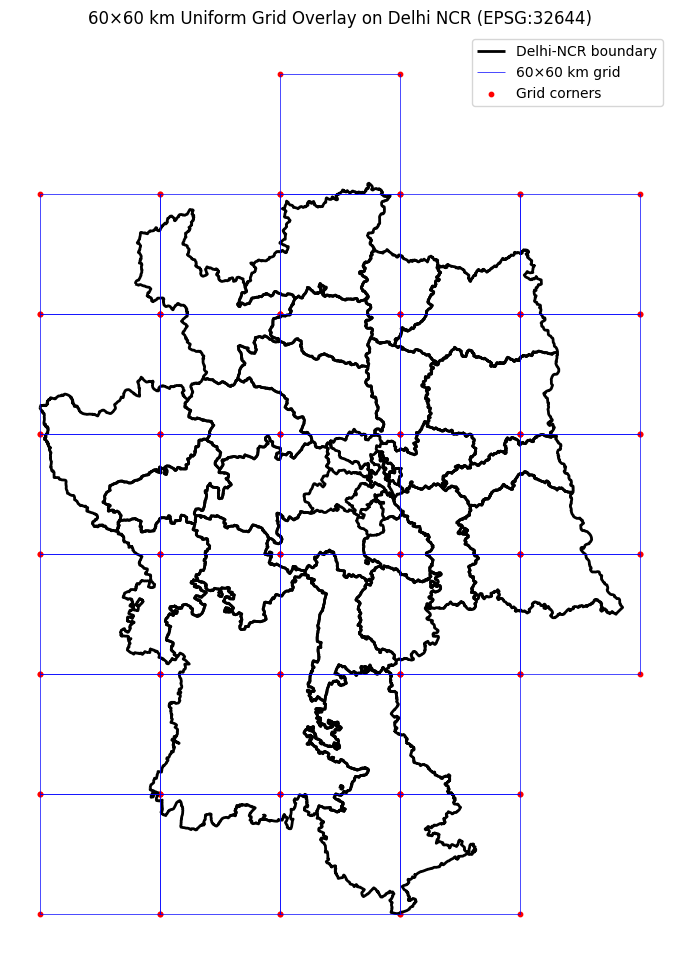

In [191]:
fig, ax = plt.subplots(figsize=(12,12))

ncr_proj.boundary.plot(ax=ax, edgecolor='black', linewidth=2, label="Delhi-NCR boundary")
grid_gdf_proj.boundary.plot(ax=ax, edgecolor='blue', linewidth=0.5, label="60×60 km grid")

corners_gdf_proj.plot(ax=ax, color='red', markersize=10, label="Grid corners")

ax.set_axis_off()
ax.set_title("60×60 km Uniform Grid Overlay on Delhi NCR (EPSG:32644)")
ax.legend()
plt.show()

## should i also plot in map using geemap.Map().add_basemap("SATELLITE") 
## as mentioned in the supporting information?

In [192]:
rgb_folder = "data/rgb/"
rgb_files = [f for f in os.listdir(rgb_folder) if f.endswith(".png")]
print(f"RGB files: {rgb_files[:5]}")

RGB files: ['28.2056_76.8558.png', '28.2056_76.8646.png', '28.2056_76.8734.png', '28.2056_76.8822.png', '28.2056_76.8910.png']


In [193]:
img = []

for f in rgb_files:
    lat_lon = f.replace(".png", "").split("_")          # lat_lon.png -> ["lat", "lon"]

    lat = float(lat_lon[0])
    lon = float(lat_lon[1])

    img.append({"filename": f, "latitude": lat, "longitude": lon})

images_df = pd.DataFrame(img)
images_df.head()

,filename,latitude,longitude
0,28.2056_76.8558.png,28.2056,76.8558
1,28.2056_76.8646.png,28.2056,76.8646
2,28.2056_76.8734.png,28.2056,76.8734
3,28.2056_76.8822.png,28.2056,76.8822
4,28.2056_76.8910.png,28.2056,76.8910


In [194]:
# save to csv
images_df.to_csv("image_centers.csv", index=False)

In [195]:
num_before = len(images_df)
print(f"Total images saved before filtering: {num_before}")

Total images saved before filtering: 9216


In [196]:

img_gdf = gpd.GeoDataFrame(images_df.copy(), 
                           geometry=gpd.points_from_xy(images_df.longitude, images_df.latitude), 
                           crs="EPSG:4326")

img_gdf_proj = img_gdf.to_crs(epsg=32644)

# Merge NCR polygons into one geometry
ncr_polygon = ncr_proj.union_all()

# Check if image centers lie inside NCR
inside_mask = img_gdf_proj.geometry.within(ncr_polygon)

# Filter images
filtered_images_gdf = img_gdf[inside_mask.values].reset_index(drop=True)

num_after = len(filtered_images_gdf)

In [197]:
print("Number of images before filtering:", num_before)
print("Number of images after filtering (centers fall in grid):", num_after)

Number of images before filtering: 9216
Number of images after filtering (centers fall in grid): 8015


In [198]:
filtered_out_csv = "filtered_images.csv"
filtered_images_gdf.to_csv(filtered_out_csv, index=False)
print("Filtered image metadata saved to:", filtered_out_csv)

filtered_images_gdf_proj = filtered_images_gdf.to_crs(epsg=32644)

Filtered image metadata saved to: filtered_images.csv


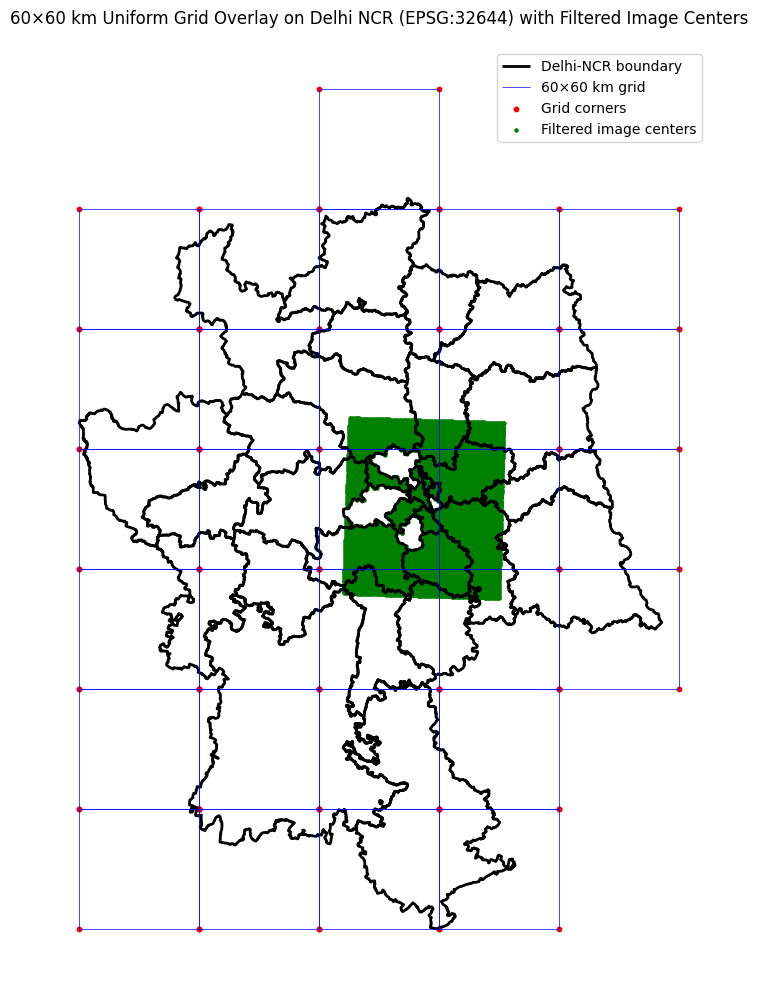

In [199]:
fig, ax = plt.subplots(figsize=(12,12))

ncr_proj.boundary.plot(ax=ax, edgecolor='black', linewidth=2, label="Delhi-NCR boundary")
grid_gdf_proj.boundary.plot(ax=ax, edgecolor='blue', linewidth=0.5, label="60×60 km grid")

corners_gdf_proj.plot(ax=ax, color='red', markersize=10, label="Grid corners")
filtered_images_gdf_proj.plot(ax=ax, color='green', markersize=5, label="Filtered image centers")

ax.set_axis_off()
ax.set_title("60×60 km Uniform Grid Overlay on Delhi NCR (EPSG:32644) with Filtered Image Centers")
ax.legend()
plt.show()

## Q2. Label Construction & Dataset Preparation
1. For each image, extract the  128×128 corresponding land-cover patch from land_cover.tif using its center coordinate 
2. Assign the image label using the dominant (mode) land-cover class.
3. Map ESA class codes to simplified land-use categories (e.g., Built-up, Vegetation, Water, Cropland, Others).
4. Perform a 60/40 train-test split randomly and visualize class distribution

In [200]:
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.windows import Window
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.model_selection import train_test_split
import json

In [201]:
FILTERED_CSV = "filtered_images.csv"
WORLD_COVER_TIF = "data/worldcover_bbox_delhi_ncr_2021.tif"

PATCH_PIXELS = 128
SENTINEL_RES_METERS = 10
PATCH_SIZE_METERS = PATCH_PIXELS * SENTINEL_RES_METERS

In [202]:
df_images = pd.read_csv(FILTERED_CSV)

gdf_images = gpd.GeoDataFrame(
    df_images,
    geometry=gpd.points_from_xy(df_images.longitude, df_images.latitude),
    crs="EPSG:4326"
)

print("Total filtered images:", len(gdf_images))

Total filtered images: 8015


In [203]:
gdf_images.head()

,filename,latitude,longitude,geometry
0,28.2056_76.8558.png,28.2056,76.8558,POINT (76.8558 28.2056)
1,28.2056_76.8646.png,28.2056,76.8646,POINT (76.8646 28.2056)
2,28.2056_76.8734.png,28.2056,76.8734,POINT (76.8734 28.2056)
3,28.2056_76.8822.png,28.2056,76.8822,POINT (76.8822 28.2056)
4,28.2056_76.8910.png,28.2056,76.8910,POINT (76.891 28.2056)


In [204]:
raster = rasterio.open(WORLD_COVER_TIF)
raster_arr = raster.read()   # shape: (bands, height, width)
raster_arr.shape

(1, 9600, 9602)

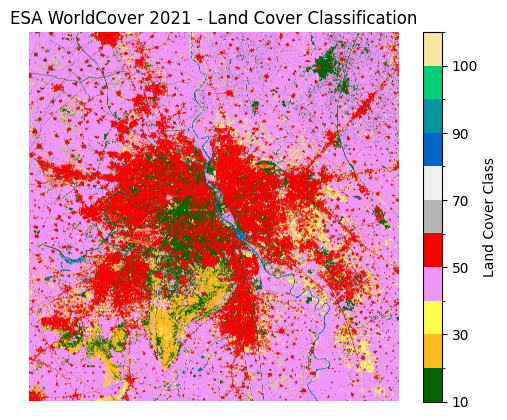

In [205]:
raster_img = raster_arr.transpose(1,2,0)  # shape: (height, width, bands)

esa_colors = [ "#006400", "#ffbb22", "#ffff4c", "#f096ff", "#fa0000", "#b4b4b4", "#f0f0f0", "#0064c8", "#0096a0", "#00cf75", "#fae6a0" ]
esa_cmap = mcolors.ListedColormap(esa_colors)
norm = mcolors.BoundaryNorm([10, 20, 30, 40, 50, 60, 70, 80, 90, 95, 100, 101], esa_cmap.N)             # for discrete classes mapping

plt.imshow(raster_img, cmap=esa_cmap, norm=norm)
plt.colorbar(label="Land Cover Class")
plt.title("ESA WorldCover 2021 - Land Cover Classification")
plt.axis("off")
plt.show()

In [206]:
print("Raster CRS:", raster.crs)
print(f"height: {raster.height} \nwidth: {raster.width} \nbands: {raster.count}")

Raster CRS: EPSG:4326
height: 9600 
width: 9602 
bands: 1


In [207]:
values, counts = np.unique(raster_arr, return_counts=True)
class_counts = dict(zip(values.tolist(), counts.tolist()))

print("ESA WorldCover Class Distribution:", json.dumps(class_counts, indent=2))

ESA WorldCover Class Distribution: {
  "0": 19200,
  "10": 9595025,
  "20": 3073217,
  "30": 6558691,
  "40": 49313882,
  "50": 21435664,
  "60": 1547683,
  "80": 599996,
  "90": 35842
}


In [208]:
esa_to_label = {
    10: "Tree_cover",
    20: "Shrubland",
    30: "Grassland",
    40: "Cropland",
    50: "Built-up",
    60: "Bare_sparse_veg",
    80: "Perm_water",
    90: "Herbaceous_wetland"
}

In [209]:
class_id = {
    "Tree_cover": 0,
    "Shrubland": 1,
    "Grassland": 2,
    "Cropland": 3,
    "Built-up": 4,
    "Bare_sparse_veg": 5,
    "Perm_water": 6,
    "Herbaceous_wetland": 7,
    "Other": 8,
}

In [210]:
def extract_patch_mode(raster_ds, x_center, y_center):

    col_center, row_center = raster_ds.index(x_center, y_center)

    half = PATCH_PIXELS // 2

    window = Window(
        col_center - half,
        row_center - half,
        PATCH_PIXELS,
        PATCH_PIXELS
    )

    arr = raster_ds.read(1, window=window, boundless=True, fill_value=0)

    flat = arr.flatten()

    valid = flat[flat != 0]             # ignore no-data pixels (esa_class = 0) 

    if len(valid) == 0:
        return None

    unique, counts = np.unique(valid, return_counts=True)

    mode_class = unique[np.argmax(counts)]

    return int(mode_class), counts.max()

In [211]:
records = []

for idx, row in gdf_images.iterrows():

    fname = row["filename"]

    x, y = row.geometry.x, row.geometry.y

    esa_class, max_count = extract_patch_mode(raster, x, y)

    if esa_class is None:
        label = "Other"
    else:
        label = esa_to_label.get(esa_class, "Other")

    records.append({
        "filename": fname,
        "latitude": row.geometry.y,
        "longitude": row.geometry.x,
        "esa_class": esa_class,
        "label": label,
        "class_id": class_id.get(label, -1),
        "class_count": max_count
    })

df_labels = pd.DataFrame(records)

print("Total labeled samples:", len(df_labels))
df_labels.head()

Total labeled samples: 8015


,filename,latitude,longitude,esa_class,label,class_id,class_count
0,28.2056_76.8558.png,28.2056,76.8558,50,Built-up,4,6614
1,28.2056_76.8646.png,28.2056,76.8646,40,Cropland,3,6375
2,28.2056_76.8734.png,28.2056,76.8734,40,Cropland,3,7667
3,28.2056_76.8822.png,28.2056,76.8822,40,Cropland,3,5891
4,28.2056_76.8910.png,28.2056,76.8910,40,Cropland,3,7148


In [212]:
df_labels.to_csv("dataset_labels.csv", index=False)

print("Saved labeled dataset.")

Saved labeled dataset.


In [213]:
train_df, test_df = train_test_split(
    df_labels,
    test_size=0.4,
    random_state=42,
    stratify=df_labels["label"]             # stratify to maintain class distribution in train/test splits
)

print("Train size:", len(train_df))
print("Test size:", len(test_df))

Train size: 4809
Test size: 3206


In [214]:
train_df['label'].unique()

array(['Built-up', 'Cropland', 'Grassland', 'Shrubland', 'Tree_cover',
       'Perm_water', 'Bare_sparse_veg', 'Herbaceous_wetland'],
      dtype=object)

In [215]:
test_df['label'].unique()

array(['Tree_cover', 'Built-up', 'Cropland', 'Shrubland', 'Grassland',
       'Perm_water', 'Bare_sparse_veg', 'Herbaceous_wetland'],
      dtype=object)

In [216]:
train_df.to_csv("train_labels.csv", index=False)
test_df.to_csv("test_labels.csv", index=False)

print("Train and test labels saved to CSV files.")

Train and test labels saved to CSV files.


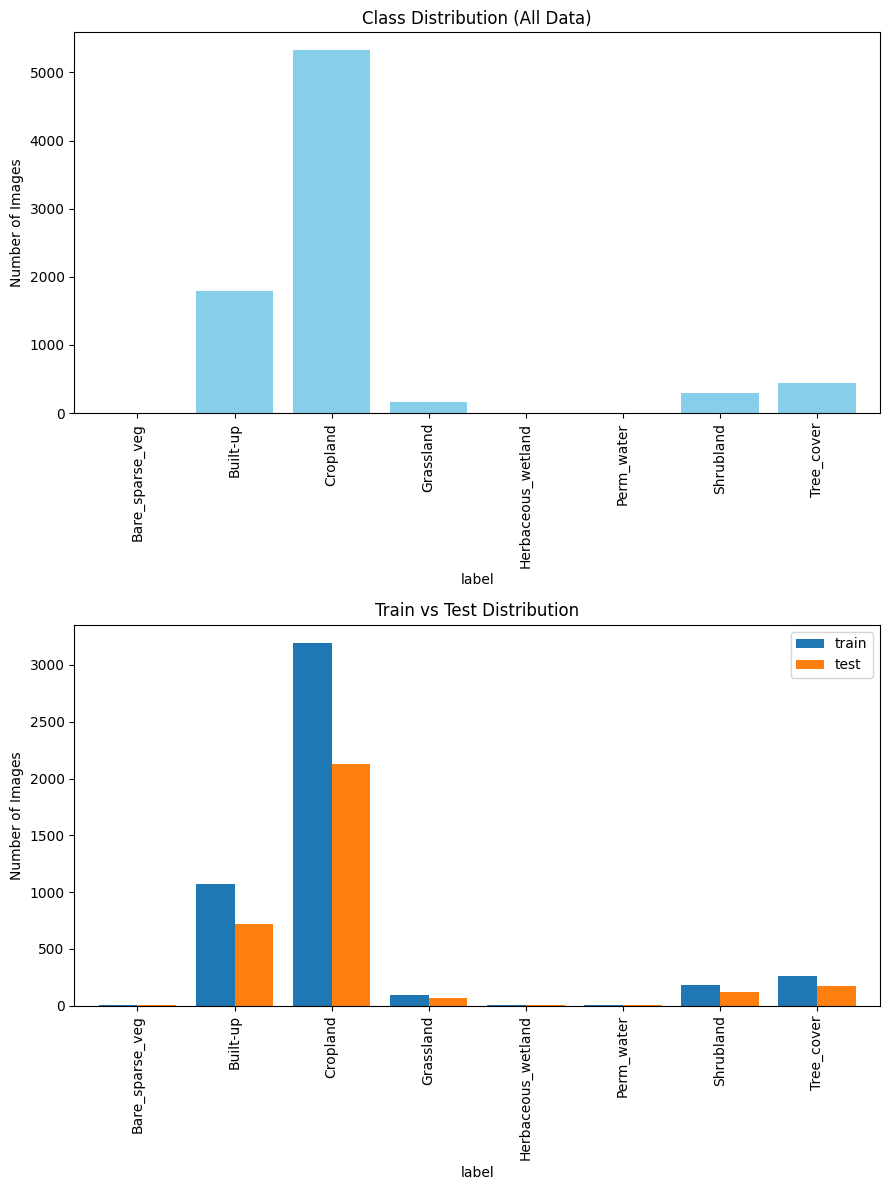

In [217]:
fig, axes = plt.subplots(2, 1, figsize=(9,12))

counts_all = df_labels["label"].value_counts().sort_index()
counts_all.plot(kind="bar", ax=axes[0], width=0.8, color="skyblue")

axes[0].set_title("Class Distribution (All Data)")
axes[0].set_ylabel("Number of Images")

train_counts = train_df["label"].value_counts().sort_index()
test_counts = test_df["label"].value_counts().sort_index()

combined = pd.DataFrame({
    "train": train_counts,
    "test": test_counts
}).fillna(0)

combined.plot(kind="bar", ax=axes[1], width=0.8)

axes[1].set_title("Train vs Test Distribution")
axes[1].set_ylabel("Number of Images")

plt.tight_layout()
plt.show()

## Q3. Model Training & Supervised Evaluation
1. Train a CNN model (e.g., ResNet18 or a simple custom CNN) for land-use classification.
2. Evaluate using accuracy and F1-score.
3. Display a confusion matrix and briefly interpret the results.

In [239]:
import os
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import seaborn as sns

In [246]:
TRAIN_CSV = "train_labels.csv"
TEST_CSV = "test_labels.csv"

IMAGE_DIR = "data/rgb"

BATCH_SIZE = 32

In [220]:
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Train samples:", len(train_df))
print("Test samples:", len(test_df))

Train samples: 4809
Test samples: 3206


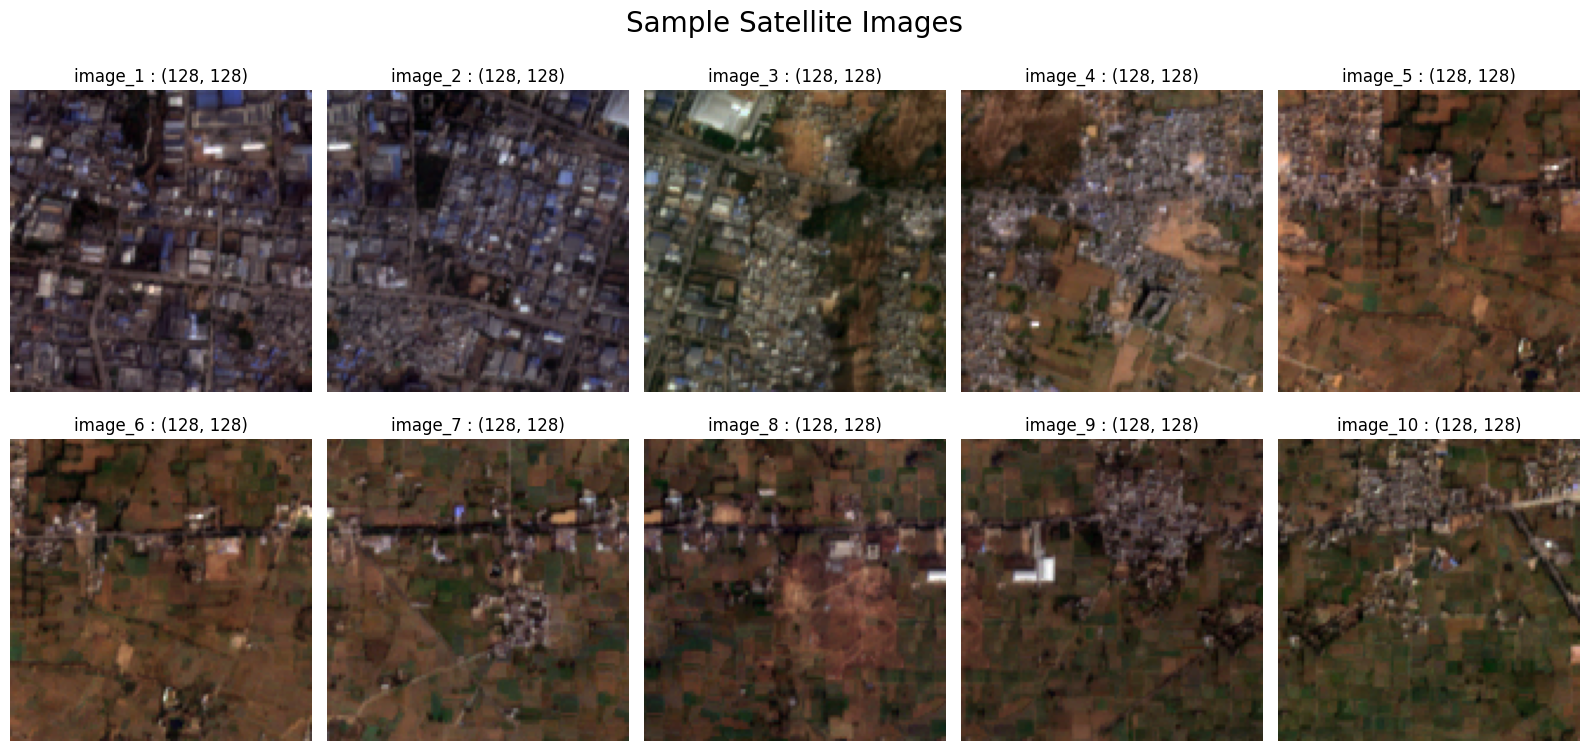

In [221]:
fig, axes = plt.subplots(2, 5, figsize=(16,8))
axes = axes.flatten()

image_files = os.listdir(IMAGE_DIR)

for i, image_name in enumerate(image_files[:10]):

    image_path = os.path.join(IMAGE_DIR, image_name)
    image = Image.open(image_path).convert("RGB")

    axes[i].imshow(image)
    axes[i].set_title(f"image_{i+1} : {image.size}")
    axes[i].axis("off")
    
fig.suptitle("Sample Satellite Images", fontsize=20)
plt.tight_layout()
plt.show()

In [222]:
image_arr = np.array(image)
print("Image shape (H, W, C):", image_arr.shape)
print(f"no. of unique pixel values: {len(np.unique(image_arr))}")
print(f"max pixel value: {np.max(image_arr)}")
print(f"min pixel value: {np.min(image_arr)}")

Image shape (H, W, C): (128, 128, 3)
no. of unique pixel values: 205
max pixel value: 254
min pixel value: 0


In [223]:
transform = A.Compose([

    A.Resize(128,128),

    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),

    A.Rotate(limit=30, p=0.5),

    A.RandomBrightnessContrast(p=0.3),
    A.GaussNoise(std_range=(0.02, 0.06), p=0.2),

    A.Normalize(
        mean=(0.485,0.456,0.406),
        std=(0.229,0.224,0.225),
        max_pixel_value=255
    ),

    ToTensorV2()
])

In [ ]:
class SatelliteDataset(Dataset):
    
    def __init__(self, dataframe, image_dir, transform=None):
        self.df = dataframe
        self.image_dir = image_dir
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        
        row = self.df.iloc[idx]
        
        img_path = os.path.join(self.image_dir, row["filename"])

        image = cv2.imread(img_path)            # img path --> numpy array (H, W, 3)    (cv2 converts to BGR while reading)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)          # BGR --> RGB
     
        label = int(row["class_id"])
        
        if self.transform:
            image = self.transform(image=image)["image"]
        
        return image, label

In [241]:
train_dataset = SatelliteDataset(train_df, IMAGE_DIR, transform)
test_dataset = SatelliteDataset(test_df, IMAGE_DIR, transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [ ]:
num_classes = train_df["class_id"].nunique()

model = models.resnet18(weights=True)

model.fc = nn.Linear(model.fc.in_features, num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = model.to(device)

c:\Users\raksh\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [247]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

NUM_EPOCHS = 10

In [249]:
if not os.path.exists("resnet18_landuse.pth"):   
    
    train_loss = []

    for epoch in range(NUM_EPOCHS):
        
        model.train()
        
        running_loss = 0
        
        for images, labels in train_loader:
            
            images = images.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            
            outputs = model(images)
            
            loss = criterion(outputs, labels)
            
            loss.backward()
            
            optimizer.step()
            
            running_loss += loss.item()
        
        avg_loss = running_loss / len(train_loader)
        train_loss.append(avg_loss)
        
        print(f"Epoch {epoch+1}/{NUM_EPOCHS}, Loss: {avg_loss:.4f}")

        torch.save(model.state_dict(), f"model_E{epoch+1}.pth")

    torch.save(model.state_dict(), "resnet18_landuse.pth")

Epoch 1/10, Loss: 0.9385
Epoch 2/10, Loss: 0.9331
Epoch 3/10, Loss: 0.9203
Epoch 4/10, Loss: 0.8997
Epoch 5/10, Loss: 0.9031
Epoch 6/10, Loss: 0.9157
Epoch 7/10, Loss: 0.9021
Epoch 8/10, Loss: 0.9085
Epoch 9/10, Loss: 0.8960
Epoch 10/10, Loss: 0.8880


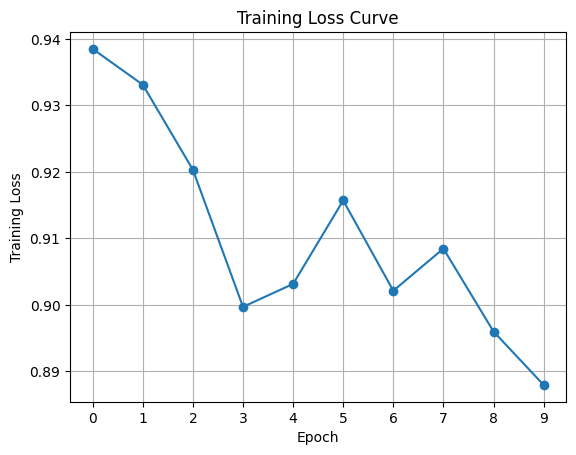

In [250]:
plt.plot(train_loss, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.xticks(range(NUM_EPOCHS))
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

In [251]:
model = models.resnet18(weights=False)
model.fc = nn.Linear(model.fc.in_features, num_classes)

model.load_state_dict(torch.load("resnet18_landuse.pth"))
model.to(device)

c:\Users\raksh\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [252]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    
    for images, labels in test_loader:
        
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        
        _, pred_label = torch.max(outputs, 1)
        
        all_preds.extend(pred_label.cpu().numpy())      # store predicted labels for evaluation
        all_labels.extend(labels.cpu().numpy())         # store true labels

In [253]:
accuracy = accuracy_score(all_labels, all_preds)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.6621958827199002


In [254]:
f1 = f1_score(all_labels, all_preds, average="weighted")

print("F1 Score:", f1)

F1 Score: 0.6154137239542272


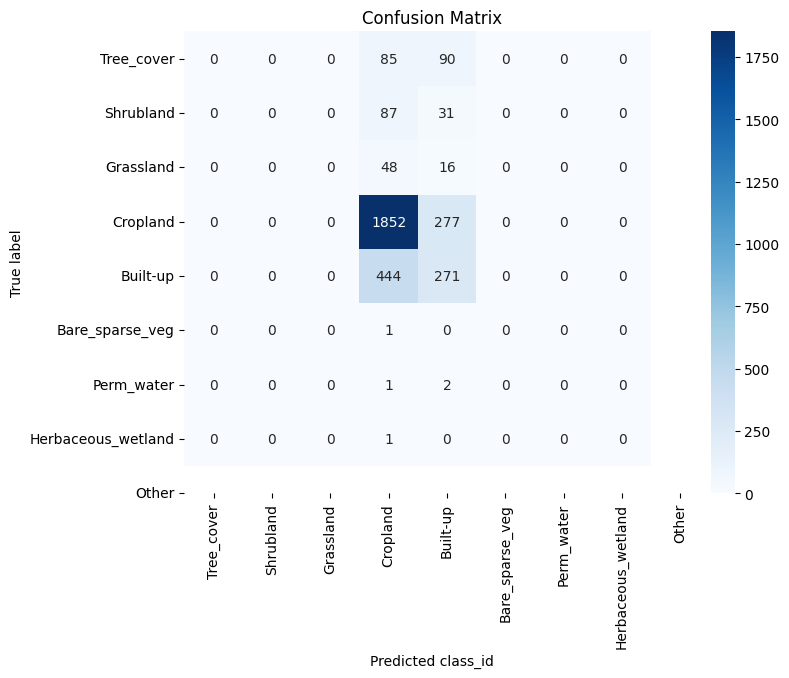

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_id.keys(),
    yticklabels=class_id.keys()
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix")

plt.show()

### Interpretation of Model Results

- The model achieves moderate test accuracy (~0.66) but predicts mainly the dominant classes (Cropland and Built-up). 
- This occurs due to strong **class imbalance** in the dataset, where Cropland constitutes the majority of samples while several classes contain very few examples. 
- As a result, the model learns to **favor majority classes**, leading to limited performance on minority land-cover categories. 

In [256]:
np.unique(all_labels)

array([0, 1, 2, 3, 4, 5, 6, 7])

In [257]:
np.unique(all_preds)

array([3, 4])

In [258]:
cm

array([[   0,    0,    0,   85,   90,    0,    0,    0],
       [   0,    0,    0,   87,   31,    0,    0,    0],
       [   0,    0,    0,   48,   16,    0,    0,    0],
       [   0,    0,    0, 1852,  277,    0,    0,    0],
       [   0,    0,    0,  444,  271,    0,    0,    0],
       [   0,    0,    0,    1,    0,    0,    0,    0],
       [   0,    0,    0,    1,    2,    0,    0,    0],
       [   0,    0,    0,    1,    0,    0,    0,    0]])